In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import seaborn.objects as so
import numpy as np
import arviz as az

plt.style.use("cppp.notebook")
theme = {**sns.axes_style("ticks"), **rcParams}
so.Plot.config.theme.update(theme)

from cppp.load import load_multisensory_data

# Model results (7 July 2026)
## Model fitting and pre-processing

Before running the analyses in this notebook, three steps (model fitting, simulation, and aggregation of model fitting results) need to be performed. Since fitting all models to all particpants can take a few days (depending on your computer), these steps have been performed and the results have been saved to the `results/` directory. 

If you want to replicate the full model fitting pipeline, you will need to run the following three steps. 

If you are interested in generating the main model figures starting from pre-processed model results, you can simply run this notebook and use the pre-generated model results / simulations.

### 1. Model fitting
Run `fit_multisensory.py` for each participant and each model ("optimal", "no_integration", "equal_integration", "vision_only") and model class ("BoundedActor", "BoundedActorPointMassDynamics"), e.g.
```bash
python fit_multisensory.py --participant 135033060 --model optimal --model_class BoundedActorPointMassDynamics
```

You can also use the script `fit_multisensory.sh` to run this for multiple participants, while running all models for one participant in pararallel. 

### 2. Model simulation
After fitting the models to the data from the baseline phase, we can simulate behaviour and save the simulated cross-correlgorams. Run `simulate_multisensory.py` for each participant and model class, e.g.
```bash
python simulate_multisensory.py --participant 135033060 --model_class BoundedActorPointMassDynamics
```

This will fill the directories `results/calibration` and `results/ccgs` with one file per model class and participants.

You can also use the script `simulate.sh` to run this for all participants.

### 3. Aggregate model fits
Finally, we need to save the model parameters and model comparison scores for each model and participant. To do this, run
```bash
python aggregate_multisensory_fits.py
```

This will create two files: `results/aggregated/loo_all_participants.csv` and `results/aggregated/summaries_all_participants.csv`

Once you have the files generated in steps 2 and 3, you can run this notebook.

## Model comparison across participants for pre-test phase 

Use Pareto-smoothed importance sampling approximation to leave-one-out cross-validation (PSIS-LOO), implemented in `arviz` (https://python.arviz.org/en/v0.22.0/api/generated/arviz.loo.html) and described by Vehtari et al. (2017, https://link.springer.com/article/10.1007/S11222-016-9696-4).

I have now stacked the data from all conditions together, so that we can get a single model comparison score for each participant using all of their baseline phase data.

In [34]:
comparison_df = pd.read_csv('../results/aggregated/pooled_model_comparison.csv', index_col=0)
print(comparison_df.columns)
# rename integration type column for nicer visualization
integration_name = {
    "optimal": "Optimal integration",
    "equal_integration": "Equal integration",
    "no_integration": "Prop. dominance",
    "vision_only": "Vis. dominance",
}
comparison_df["integration"] = comparison_df["integration"].map(integration_name)

# rename dynamics model type column (for nicer visualization)
comparison_df["dynamics"] = comparison_df["model"].map(
    {"BoundedActorPointMassDynamics": "Point mass", "BoundedActor": "Velocity control"}
)

# compute the lower and upper bounds of ELPD 95 % CIs (+- 1.96 * se) of the ELPD-LOO sum for each model
comparison_df["elpd_low"] = comparison_df["elpd_pooled"] - 1.96 * comparison_df["se_diff"]
comparison_df["elpd_high"] = comparison_df["elpd_pooled"] + 1.96 * comparison_df["se_diff"]

Index(['integration', 'model', 'elpd_pooled', 'elpd_diff', 'se_diff',
       'n_pooled_points', 'is_reference'],
      dtype='object')


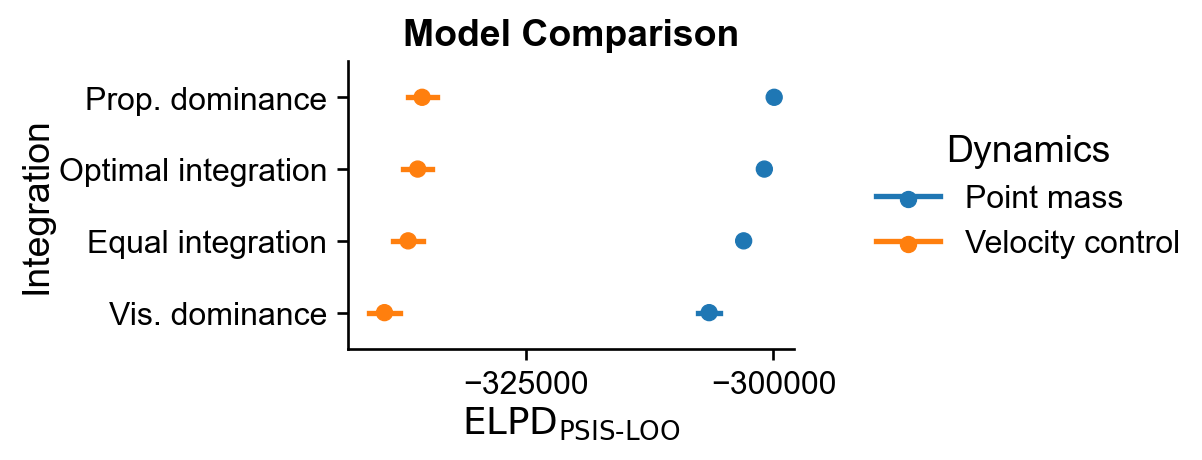

In [35]:

g = (so.Plot(comparison_df, y="integration", x="elpd_pooled", color="dynamics")
      .add(so.Dot())
      .add(so.Range(), xmin="elpd_low", xmax="elpd_high")
      # .add(so.Dot(pointsize=2), so.Jitter())
      .layout(size=(4.5,2.5))
      .scale(y=so.Nominal(),
             x=so.Continuous().tick(upto=2))
      .label(x=r"$\text{ELPD}_{\text{PSIS-LOO}}$", y="Integration", color="Dynamics", title="Model Comparison")
)
g.save("../figures/multisensory_model_comparison.svg")

In [7]:
loo_df = pd.read_csv('../results/aggregated/loo_all_participants.csv', index_col=0)
participants = loo_df["participant"].unique()

In [8]:
# rename integration type column for nicer visualization
integration_name = {
    "optimal": "Optimal integration",
    "equal_integration": "Equal integration",
    "no_integration": "Prop. dominance",
    "vision_only": "Vis. dominance",
}
loo_df["integration"] = loo_df["integration"].map(integration_name)

# rename dynamics model type column (for nicer visualization)
loo_df["dynamics"] = loo_df["model"].map(
    {"BoundedActorPointMassDynamics": "Point mass", "BoundedActor": "Velocity control"}
)

# create fixed order of models for plotting and set up color palette
model_order = ["Optimal integration", "Equal integration", "Prop. dominance", "Vis. dominance"]
palette = dict(zip(model_order, sns.color_palette("colorblind", 4)))

In [9]:
# sum up ELPDs across participants for each model, and compute the standard error of the sum
group_stats = (
    loo_df.groupby(["integration", "dynamics"])
    .apply(lambda x: pd.Series({
        "elpd_sum": x["elpd"].sum(),
        "se_sum": np.sqrt((x["se"] ** 2).sum()),
    }))
    # .reindex(model_order)
    .reset_index()
)

# compute the lower and upper bounds of ELPD 95 % CIs (+- 1.96 * se) of the ELPD-LOO sum for each model
group_stats["elpd_low"] = group_stats["elpd_sum"] - 1.96 * group_stats["se_sum"]
group_stats["elpd_high"] = group_stats["elpd_sum"] + 1.96 * group_stats["se_sum"]


/tmp/ipykernel_3022174/98422786.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


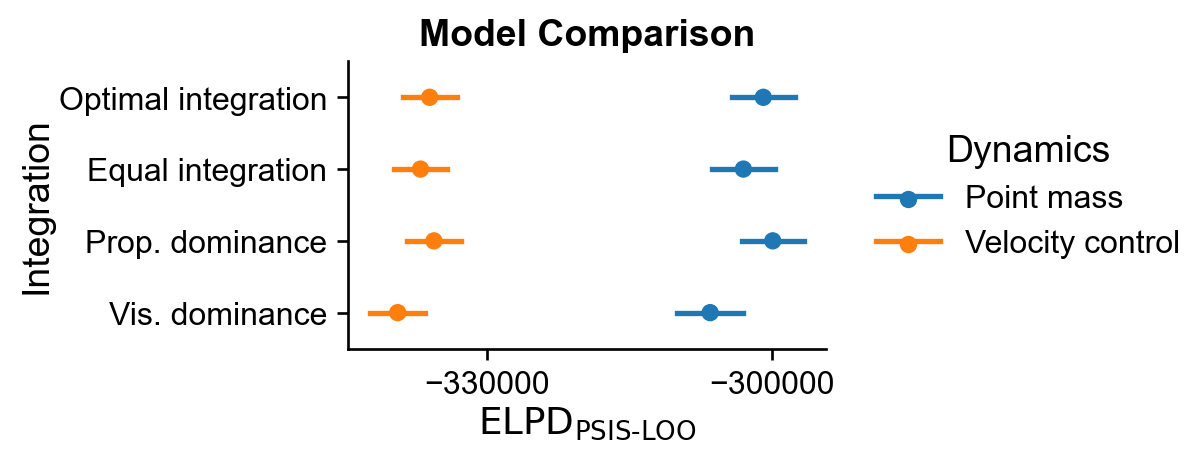

In [10]:

g = (so.Plot(group_stats, y="integration", x="elpd_sum", color="dynamics")
      .add(so.Dot())
      .add(so.Range(), xmin="elpd_low", xmax="elpd_high")
      # .add(so.Dot(pointsize=2), so.Jitter())
      .layout(size=(4.5,2.5))
      .scale(y=so.Nominal(order=model_order),
             x=so.Continuous().tick(upto=2))
      .label(x=r"$\text{ELPD}_{\text{PSIS-LOO}}$", y="Integration", color="Dynamics", title="Model Comparison")
)
g.save("../figures/multisensory_model_comparison.svg")

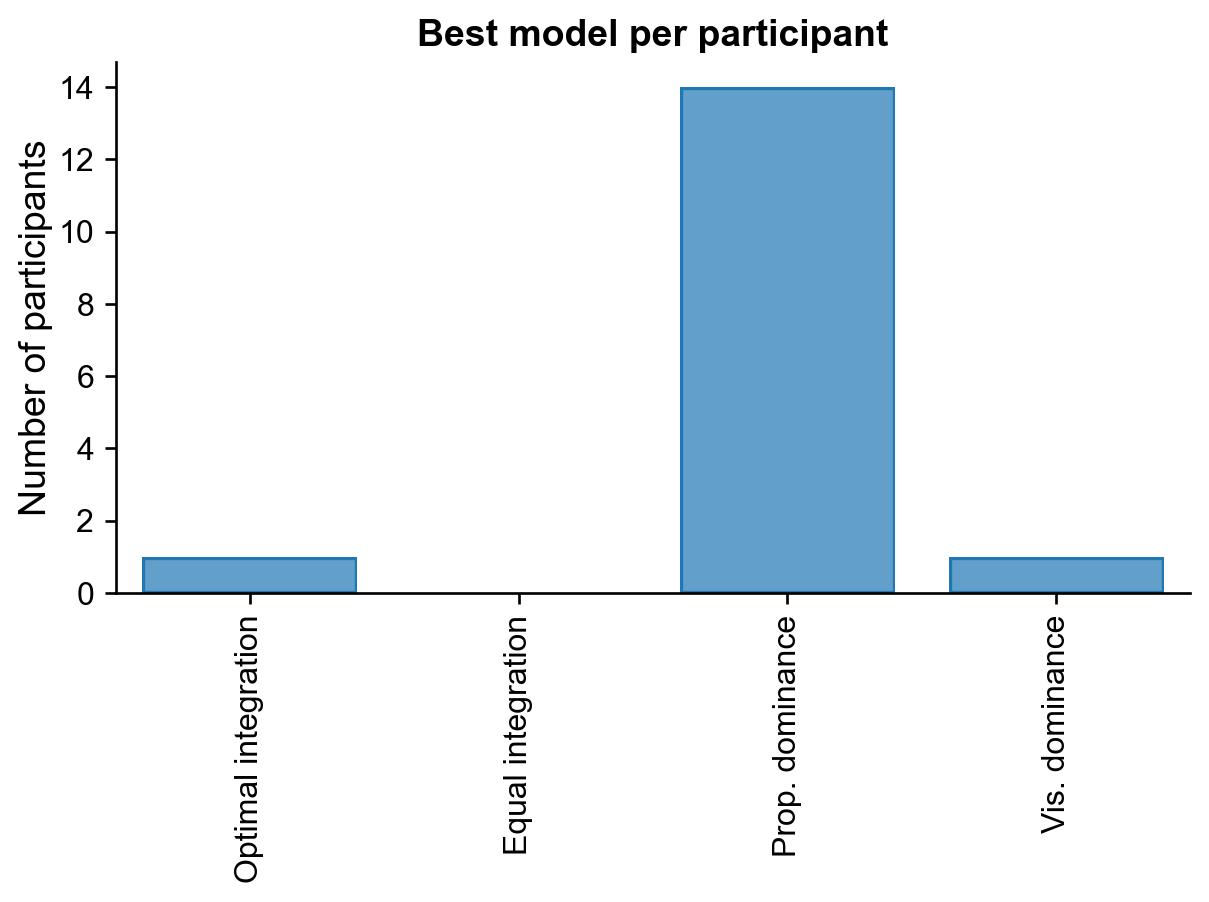

In [11]:
# get the best-fitting model per participant
best_per_participant = (
    loo_df.loc[loo_df.groupby("participant")["elpd"].idxmax(), ["integration", "dynamics", "participant"]]
)

win_counts = (
    best_per_participant["integration"].value_counts()
    .reindex(model_order, fill_value=0)
    .reset_index()
)
win_counts.columns = ["integration", "wins"]
win_counts["n_participants"] = win_counts["wins"] 

g = (
    so.Plot(win_counts, x="integration", y="n_participants")
    .add(so.Bar())
    .scale(x=so.Nominal())
    .label(x="", y="Number of participants", title="Best model per participant")
).plot()
for axis in g._figure.axes:
    axis.xaxis.set_tick_params(rotation=90)
g

## Parameter estimates (uncertainty, cost, variability) 

In [18]:
# read data frame containing parameter estimate summaries
summary_df = pd.read_csv("../results/aggregated/summaries_all_participants.csv", index_col = 0)

# rename columns containg model type for integration and dynamics
summary_df["integration"] = summary_df["integration"].map(integration_name)
summary_df["dynamics"] = summary_df["model"].map({ "BoundedActorPointMassDynamics": "Point mass", "BoundedActor": "Velocity control" })


In [19]:
param_names = {"sigma_prop": "Hand", "sigma_vis[0]": "Cursor", "sigma_vis[1]": "Cloud",
               "action_variability": "Action variability", "action_cost": "Action cost", 
               "vis_prop_diff[0]": "Cursor - hand", "vis_prop_diff[1]": "Cloud - hand"}

# get the parts of df that correspond to the best model for each participant
best_model_params = summary_df.merge(best_per_participant, on=["participant", "integration", "dynamics"])
best_model_params["parameter"] = best_model_params["parameter"].map(lambda x: param_names.get(x, x))
summary_df["parameter"] = summary_df["parameter"].map(lambda x: param_names.get(x, x))


### Perceptual uncertainty 

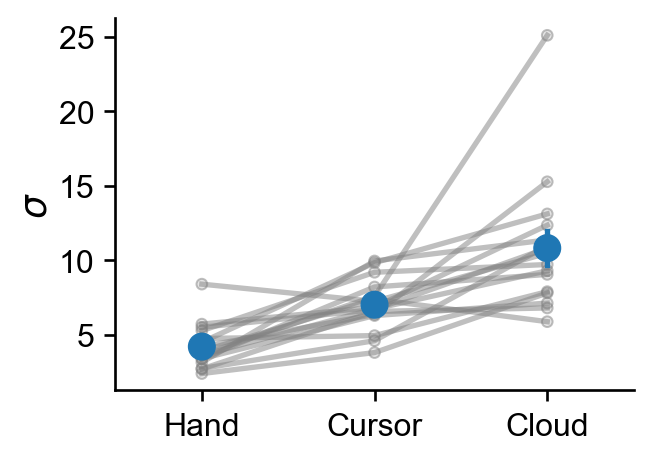

In [20]:
g = (
    so.Plot(
        best_model_params[
           (best_model_params["parameter"].isin(
                    ["Hand", "Cursor", "Cloud"]
                )
            )
        ],
        x="parameter",
        y="mean",
        # color="participant",
    )
    .add(so.Dots(color="gray", alpha=0.5), group="participant")
    .add(so.Line(color="gray", alpha=0.5), group="participant")
    .add(so.Dot(pointsize=10, artist_kws={"zorder": 10}), so.Agg())
    .add(so.Range(artist_kws={"zorder": 10}), so.Est(errorbar="se"))
    # .add(so.Dot(), so.Agg())
    # .add(so.Range(), so.Est(errorbar="se"))
    # .limit(y=(0, 25.0))
    .label(x="", y=r"$\sigma$")
    .layout(size=(3.5, 2.5))
    .scale(color=so.Nominal())
    # .facet(col="parameter")
    # .share(y=False)
)
g.save("../figures/multisensory_model_parameters.svg")

We tested whether proprioceptive uncertainty was lower than visual uncertainty by computing the posterior distribution of the difference between the proprioceptive and both visual uncertainty parameters. The 94% highest-density interval was fully above zero in 16 out of 16 participants for the difference between cursor and and and in 14 out of 16 participants for the difference between cloud and hand. This indicates that proprioceptive uncertainty was lower than visual uncertainty in most participants.

Feel free to run other kinds of stats to compare the parameter estimates if you like.

In [15]:
best_model_params[best_model_params["parameter"].isin(["Cursor - hand", "Cloud - hand"])].groupby(["parameter"]).apply(lambda x: (x["hdi_3%"] > 0.).sum())

/tmp/ipykernel_3022174/435023660.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_model_params[best_model_params["parameter"].isin(["Cursor - hand", "Cloud - hand"])].groupby(["parameter"]).apply(lambda x: (x["hdi_3%"] > 0.).sum())


parameter
Cloud - hand     16
Cursor - hand    14
dtype: int64

### Action cost and variability

Note: the action variability parameter can be interpreted in the same units as the data, whereas the action cost parameter is unitless, so the y axis does not have the same interpretation.

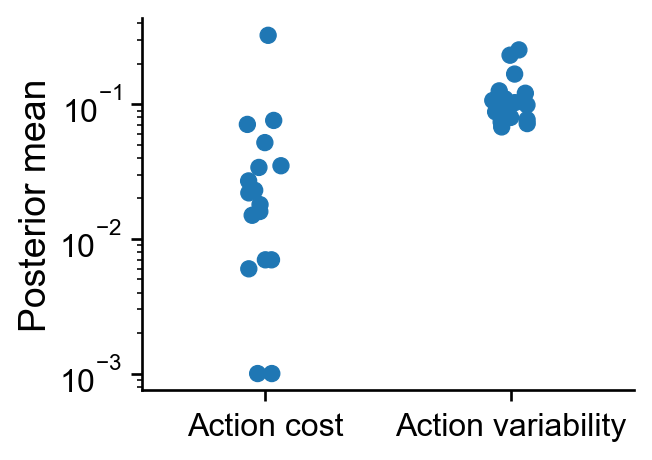

In [ ]:
g = (
    so.Plot(
        best_model_params[
            (
                best_model_params["parameter"].isin(
                    ["Action cost", "Action variability"]
                )
            )
        ],
        x="parameter",
        y="mean",
        # color="model_short",
    )
    .add(so.Dot(), so.Jitter())
    # .add(so.Line(), group="participant")
    # .add(so.Dot(), so.Agg())
    # .add(so.Range(), so.Est(errorbar="se"))
    # .limit(y=(0, 1.0))
    .label(x="", y="Posterior mean")
    .scale(color=so.Nominal(), y="log")
    # .facet(col="parameter")
    .layout(size=(3.5, 2.5))
)


## Posterior predictive for a representative participant

Plotting trajectories for participant 

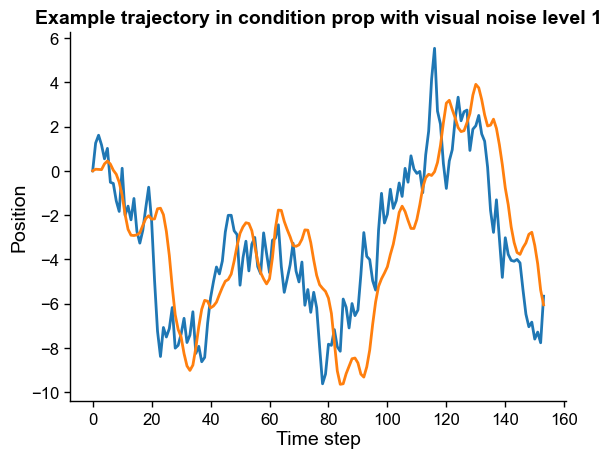

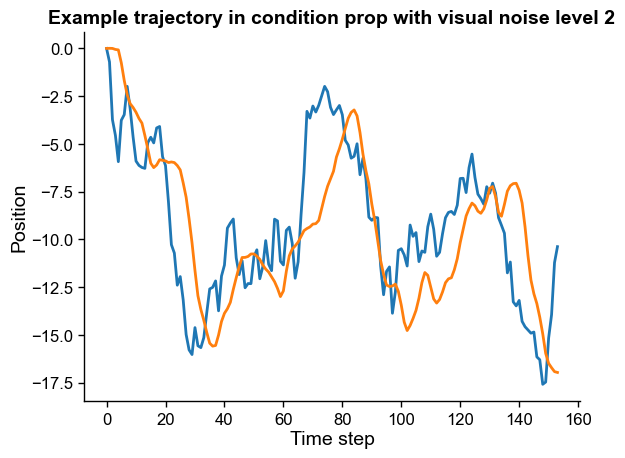

In [21]:
example_participant = 765738475
example_participant_model = az.from_netcdf(f"../results/multisensory-mcmc-{example_participant}_1_2_7452_2000_2500_4_no_integration_BoundedActorPointMassDynamics_['prop', 'vis', 'multi'].nc")


for vis_noise in [1, 2]:
    condition = "prop"
    sim_data = example_participant_model.posterior_predictive[f"x_{condition}_{vis_noise}"]

    # just pick one 'random' sample
    chain_idx = 0
    sample_idx = 100
    plt.figure()
    plt.plot(sim_data[chain_idx, sample_idx, :, 0])
    plt.plot(sim_data[chain_idx, sample_idx, :, 1])
    plt.xlabel("Time step")
    plt.ylabel("Position")
    plt.title(f"Example trajectory in condition {condition} with visual noise level {vis_noise}")

## Load and plot simulated CCGs

We load the posterior-predictive checks for the cross-correlograms.

In [23]:
model_classes = ["BoundedActorPointMassDynamics", "BoundedActor"]
ccgs = pd.concat([pd.read_csv(f"../results/ppc/multisensory-simulations-ppc-{p}_1_2_3_2500_2500_4_{model_class}_['prop', 'vis', 'multi'].csv") for p in participants for model_class in model_classes]).reset_index(drop=True)

ccgs["Condition"] = ccgs["condition"].map({"vis": "Vision", "prop": "Proprioception", "multi": "Multisensory"})
ccgs["Visual target"] = ccgs["vis_noise"].map({1: "Cursor", 2: "Cloud"})
ccgs["integration"] = ccgs["model"].map(integration_name)
ccgs["dynamics"] = ccgs["model_class"].map({ "BoundedActorPointMassDynamics": "Point mass", "BoundedActor": "Velocity control" })

Plotting model Point mass


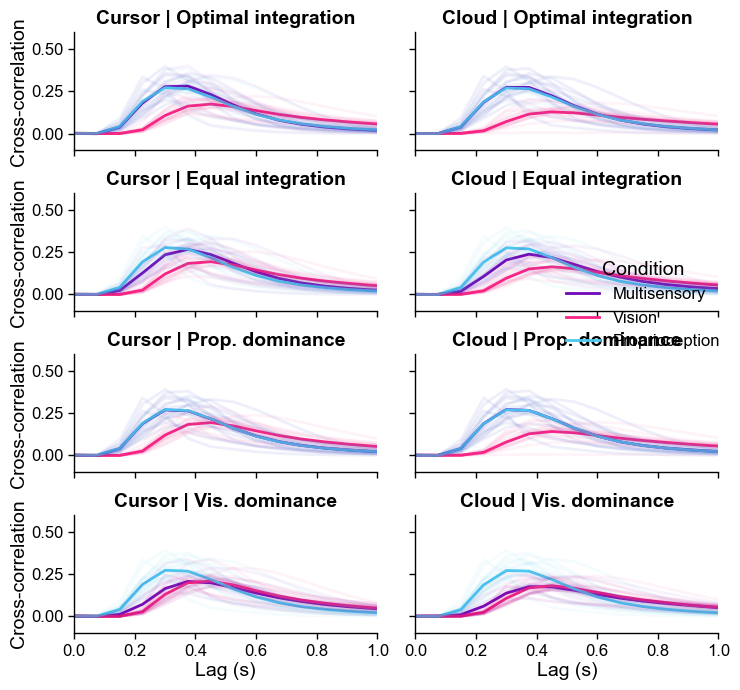

Plotting model Velocity control


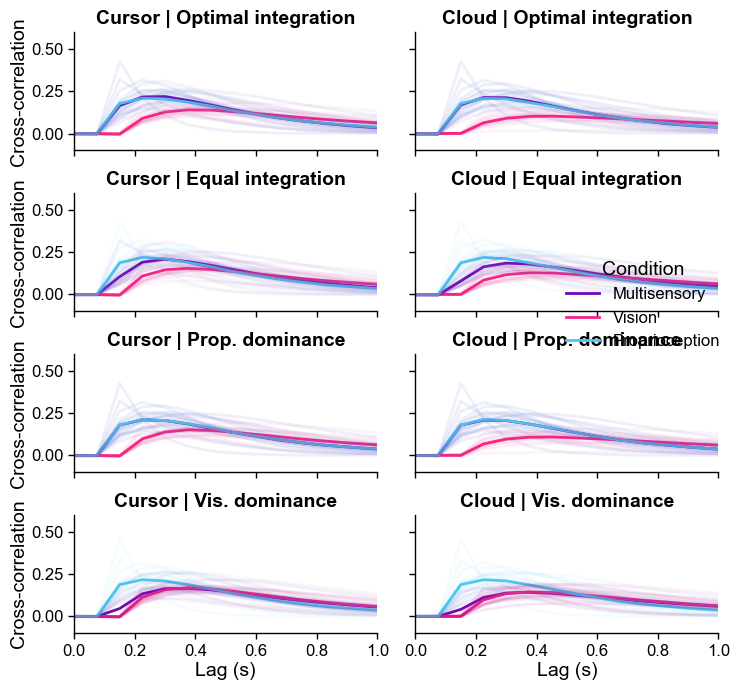

In [25]:

palette = {'Vision': "#F72585", 'Proprioception':  "#4CC9F0", 'Multisensory': "#7209B7"}
for model_class in ccgs["dynamics"].unique():
    print(f"Plotting model {model_class}")
    g = (so.Plot(ccgs[ccgs["dynamics"] == model_class], x="lag", y="correlation", color="Condition")
        .add(so.Line(), so.Agg())
        .add(so.Line(alpha=0.05), so.Agg(), group="participant")
        # .add(so.Band(), so.Est())
        .facet(col="Visual target",  
        row="integration", order={"row": model_order}
            )
        .label(x="Lag (s)", y="Cross-correlation")
        .limit(x=(-0.0, 1.0), y=(-0.1, 0.6))
        # .scale(color=so.Nominal({"vis": sns.color_palette("colorblind")[3], "prop": sns.color_palette("colorblind")[0], "multi": sns.color_palette("colorblind")[4]}))
        .scale(color=so.Nominal(palette))
        .layout(size=(7.5, 7.0))
    )
    g.show()

## CCG parameters (peak)

In [26]:
ccg_params = ccgs.groupby(["participant", "integration", "dynamics", "Condition", "Visual target"]).apply(
    lambda g: pd.Series({
        'peak': g['correlation'].max(),
        'lag': g.loc[g['correlation'].idxmax(), 'lag']
    }),
    include_groups=False
).reset_index()

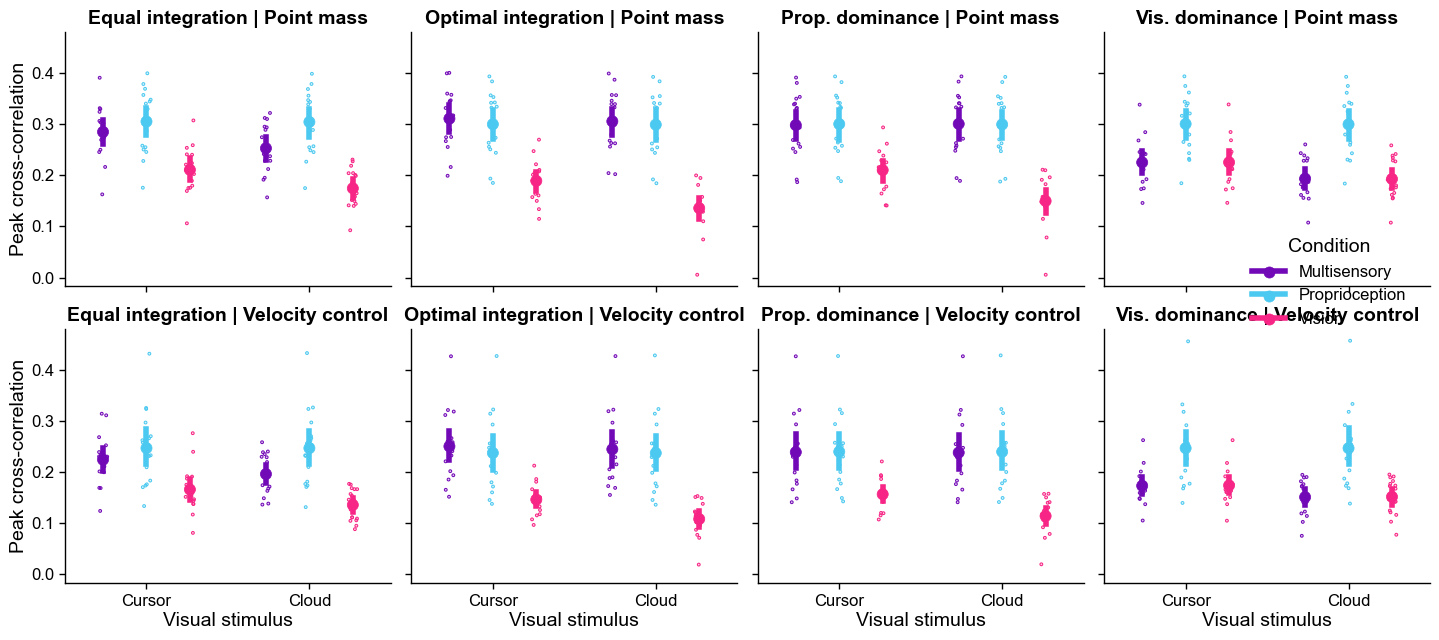

In [28]:
g = (so.Plot(ccg_params, x="Visual target", y="peak", color="Condition")
    .add(so.Dot(pointsize=8), so.Agg(), so.Dodge())
    .add(so.Dots(pointsize=2), so.Dodge(), so.Jitter())
    .add(so.Range(linewidth=4), so.Est(errorbar="ci"), so.Dodge())
    .facet(col="integration", row="dynamics")
    .scale(x=so.Nominal(order=["Cursor", "Cloud"]), color=so.Nominal(palette))
    .label(x="Visual stimulus", y="Peak cross-correlation")
    .layout(size=(14.5, 6.5))
    # .share(y=False)
)

g.show()

## Compare data and simulations in calibration phase


First, we load the model simulations in the offset phase for all participants 

In [29]:
df_sim = pd.concat([pd.read_csv(f"../results/calibration/multisensory-simulations-calibration-{p}_1_2_3_2500_2500_4_{model_class}_['prop', 'vis', 'multi'].csv") for p in participants for model_class in model_classes]).reset_index(drop=True)

df_sim["tracking_error"] = df_sim["lefty_pos"] - (df_sim["righty_pos"])

df_sim["offset_sign"] = df_sim.groupby("participant")["cursor_offset"].transform(
    lambda x: np.sign(x.mean())
)

df_sim["tracking_error"] *= df_sim["offset_sign"]


In [30]:
df_sim["abs_cursor_offset"] = df_sim["cursor_offset"].abs()

df_sim["integration"] = df_sim["model"].map(integration_name)
df_sim["dynamics"] = df_sim["model_class"].map({ "BoundedActorPointMassDynamics": "Point mass", "BoundedActor": "Velocity control" })
df_sim["Visual target"] = df_sim["vis_noise"].map({1: "Cursor", 2: "Cloud"})
df_sim["Visual uncertainty"] = df_sim["vis_noise"].map({1: "Low", 2: "High"})

In [31]:
#  "Optimal integration", "No integration"

mean_df = (
    df_sim[
        (df_sim["phase"].isin(["calibration"]))
    ]
    .groupby(["trial_number", "integration", "dynamics", "Visual uncertainty", "participant"])[
        ["tracking_error", "abs_cursor_offset"]
    ]
    .median()
    .reset_index()
)


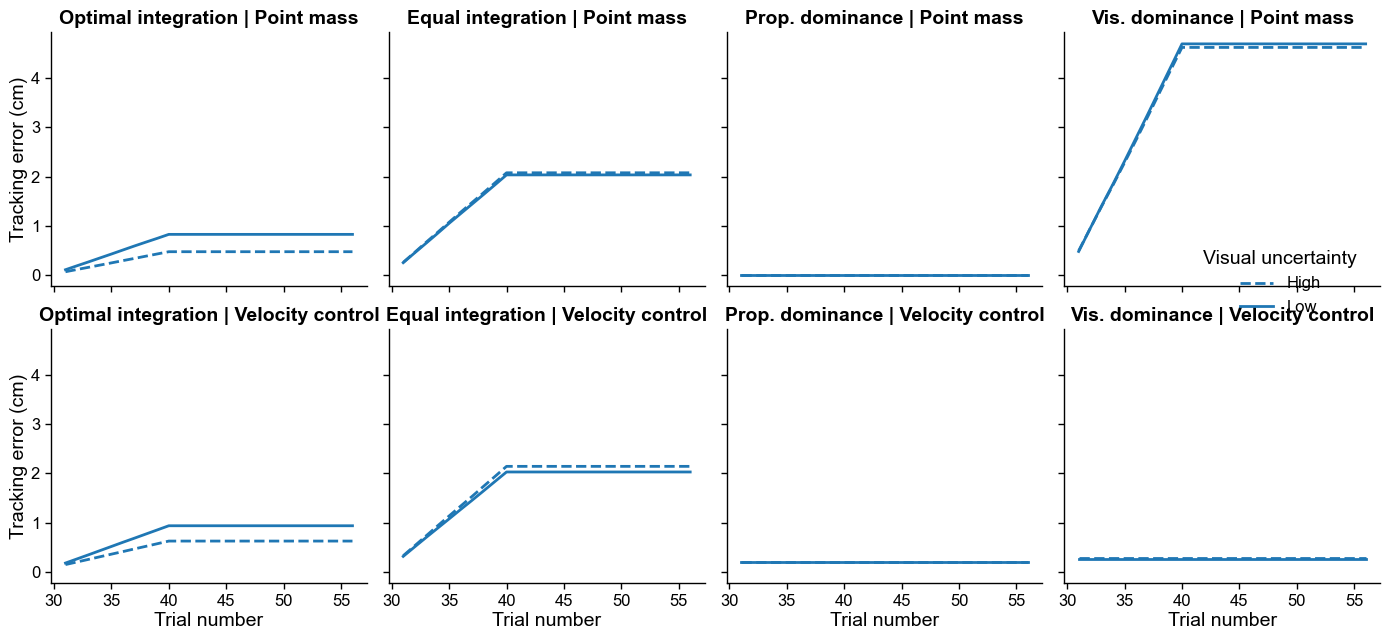

In [32]:
g = (
    so.Plot(
        mean_df,
        x="trial_number",
        y="tracking_error",
        linestyle="Visual uncertainty",
    )
    .add(so.Line(), so.Agg("mean"))
    # .add(so.Line(color="gray"), so.Agg(), y="abs_cursor_offset", color=None)
    # .add(so.Band(), so.Est(errorbar="ci"))
    # .add(so.Line(alpha=0.1), so.Agg(), group="participant")
    .scale(linestyle=so.Nominal({"Low": "-", "High": "--"}))
    .facet(col="integration", order={"col": model_order}, row="dynamics")
    .layout(size=(14, 6.5))
    .label(x="Trial number", y="Tracking error (cm)")
)
g.show()